# Notebook 07 - Visualisation

This notebook produces all final visualisations for the CRI project. All charts are saved as PNG files to `report/figures/` for use in the written report.

**Charts produced:**
1. Bar chart - top 20 countries by CRI score
2. Bar chart - all 35 countries by CRI score
3. Grouped bar chart - all four sub-index scores per country (top 20)
4. Heatmap - sub-index scores for all countries
5. Choropleth world map - CRI scores by country
6. Radar chart - top 5 countries across all four sub-indices

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from math import pi
from IPython.display import display

PROCESSED = '../data/processed/'
FIGURES = '../report/figures/'

df = pd.read_csv(f'{PROCESSED}cri_scores.csv')

SUB_INDEX_COLS = [
    'technical_capacity',
    'legal_regulatory',
    'capacity_building',
    'organisational_measures',
]
# Only keep sub-index columns that exist in the file
SUB_INDEX_COLS = [c for c in SUB_INDEX_COLS if c in df.columns]

print(f'Loaded shape: {df.shape}')
print(f'Sub-index columns: {SUB_INDEX_COLS}')
display(df.head())

Loaded shape: (35, 10)
Sub-index columns: ['technical_capacity', 'legal_regulatory', 'capacity_building', 'organisational_measures']


,country,technical_capacity,legal_regulatory,capacity_building,organisational_measures,cri_score,cri_rank,gci_overall,hdi_score,gdp_per_capita
0,United Kingdom,0.944173,1.0,1.000000,1.000000,0.986043,1,99.54,0.940,49944.470212
1,Spain,0.937356,1.0,0.992307,0.974052,0.975929,2,98.52,0.911,33493.222541
2,Estonia,0.852825,1.0,0.976968,1.000000,0.957448,3,99.48,0.899,30264.006489
3,Germany,0.887191,1.0,0.982378,0.959229,0.957200,4,97.41,0.950,54776.766824
4,Portugal,0.906974,1.0,0.946626,0.974052,0.956913,5,97.32,0.874,27634.618314


## 1. Bar Chart - Top 20 Countries by CRI Score

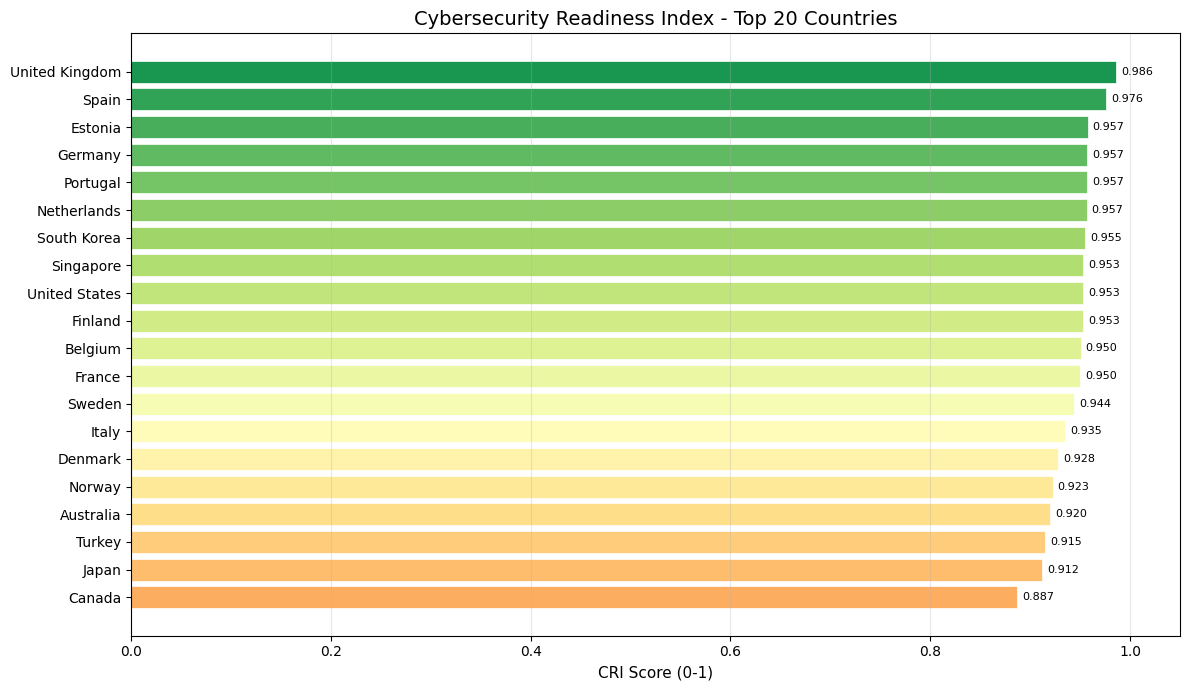

Saved: report/figures/07_top20_bar.png


In [3]:
top20 = df.sort_values('cri_score', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top20['country'][::-1],
    top20['cri_score'][::-1],
    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top20))),
    edgecolor='white',
    linewidth=0.5
)

# Add score labels
for bar in bars:
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():.3f}',
        va='center', fontsize=8
    )

ax.set_xlabel('CRI Score (0-1)', fontsize=11)
ax.set_title('Cybersecurity Readiness Index - Top 20 Countries', fontsize=14)
ax.set_xlim(0, 1.05)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}07_top20_bar.png', dpi=150)
plt.show()
print('Saved: report/figures/07_top20_bar.png')

## 2. Full CRI Ranking - All 35 Countries

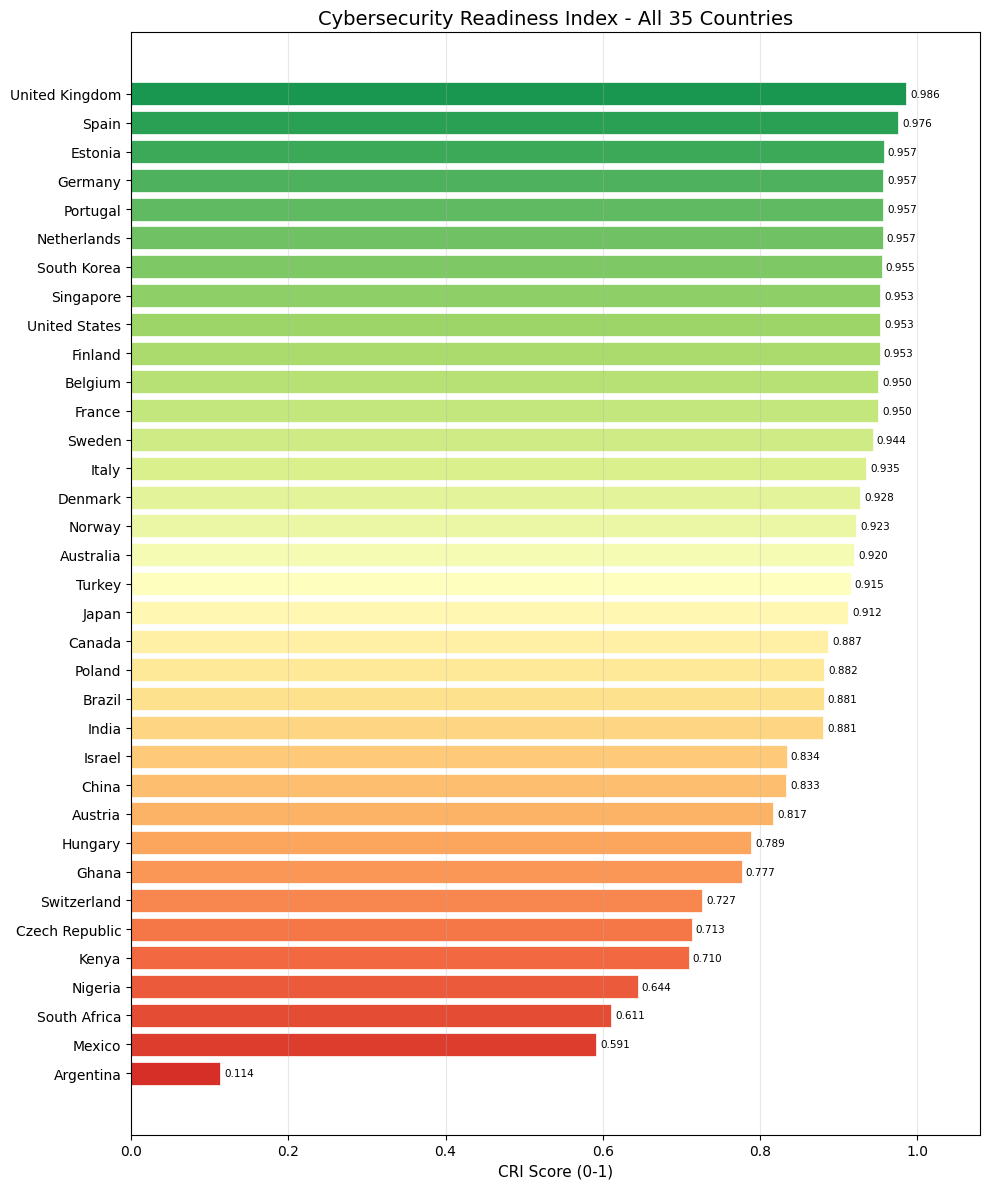

Saved: report/figures/07_all_countries_bar.png


In [4]:
all_countries = df.sort_values('cri_score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
colors = plt.cm.RdYlGn(np.linspace(0.1, 0.9, len(all_countries)))
bars = ax.barh(all_countries['country'], all_countries['cri_score'],
               color=colors, edgecolor='white', linewidth=0.5)

for bar in bars:
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{bar.get_width():.3f}', va='center', fontsize=7.5)

ax.set_xlabel('CRI Score (0-1)', fontsize=11)
ax.set_title('Cybersecurity Readiness Index - All 35 Countries', fontsize=14)
ax.set_xlim(0, 1.08)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}07_all_countries_bar.png', dpi=150)
plt.show()
print('Saved: report/figures/07_all_countries_bar.png')

## 3. Grouped Bar Chart - Sub-Index Scores for Top 20 Countries

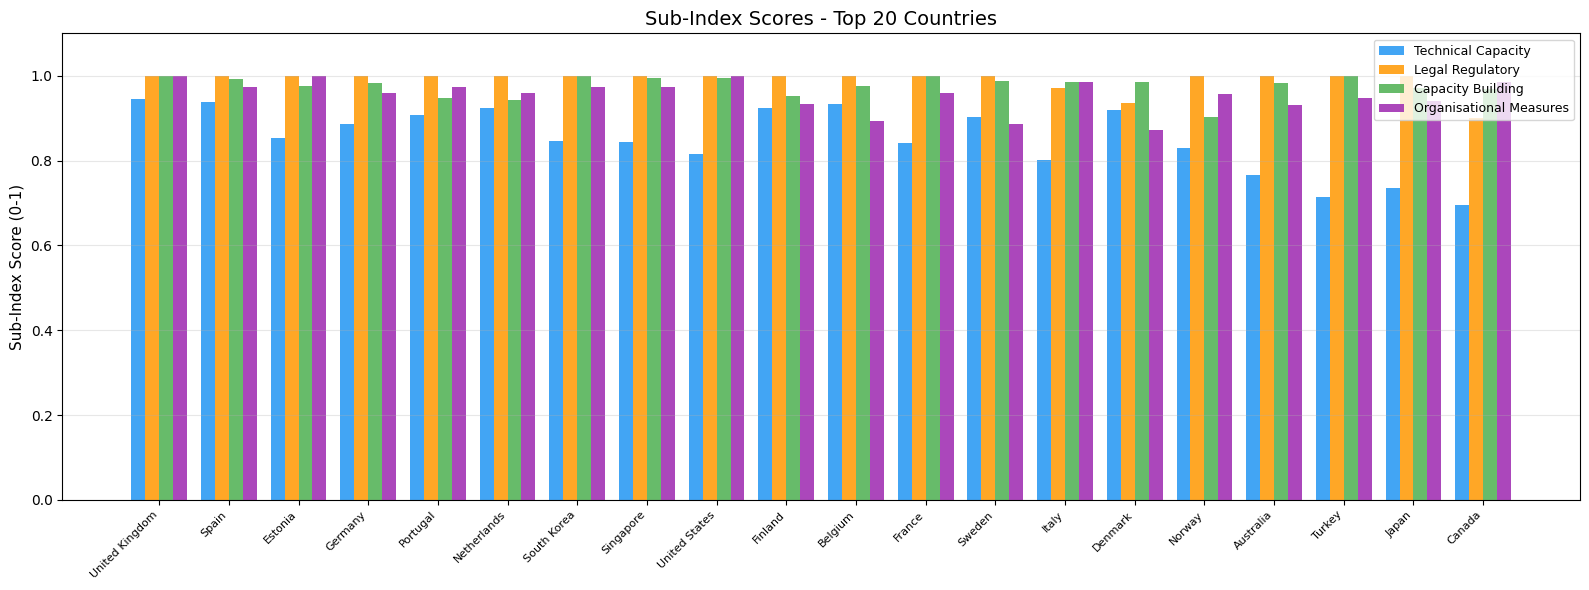

Saved: report/figures/07_subindex_grouped_bar.png


In [5]:
top20_grouped = df.sort_values('cri_score', ascending=False).head(20).reset_index(drop=True)

n_countries = len(top20_grouped)
n_subs = len(SUB_INDEX_COLS)
x = np.arange(n_countries)
width = 0.8 / n_subs
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, ax = plt.subplots(figsize=(16, 6))

for i, (col, color) in enumerate(zip(SUB_INDEX_COLS, colors)):
    offset = (i - n_subs / 2 + 0.5) * width
    ax.bar(
        x + offset,
        top20_grouped[col],
        width=width,
        label=col.replace('_', ' ').title(),
        color=color,
        alpha=0.85
    )

ax.set_xticks(x)
ax.set_xticklabels(top20_grouped['country'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sub-Index Score (0-1)', fontsize=11)
ax.set_title('Sub-Index Scores - Top 20 Countries', fontsize=14)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{FIGURES}07_subindex_grouped_bar.png', dpi=150)
plt.show()
print('Saved: report/figures/07_subindex_grouped_bar.png')

## 4. Heatmap - Sub-Index Scores for All Countries

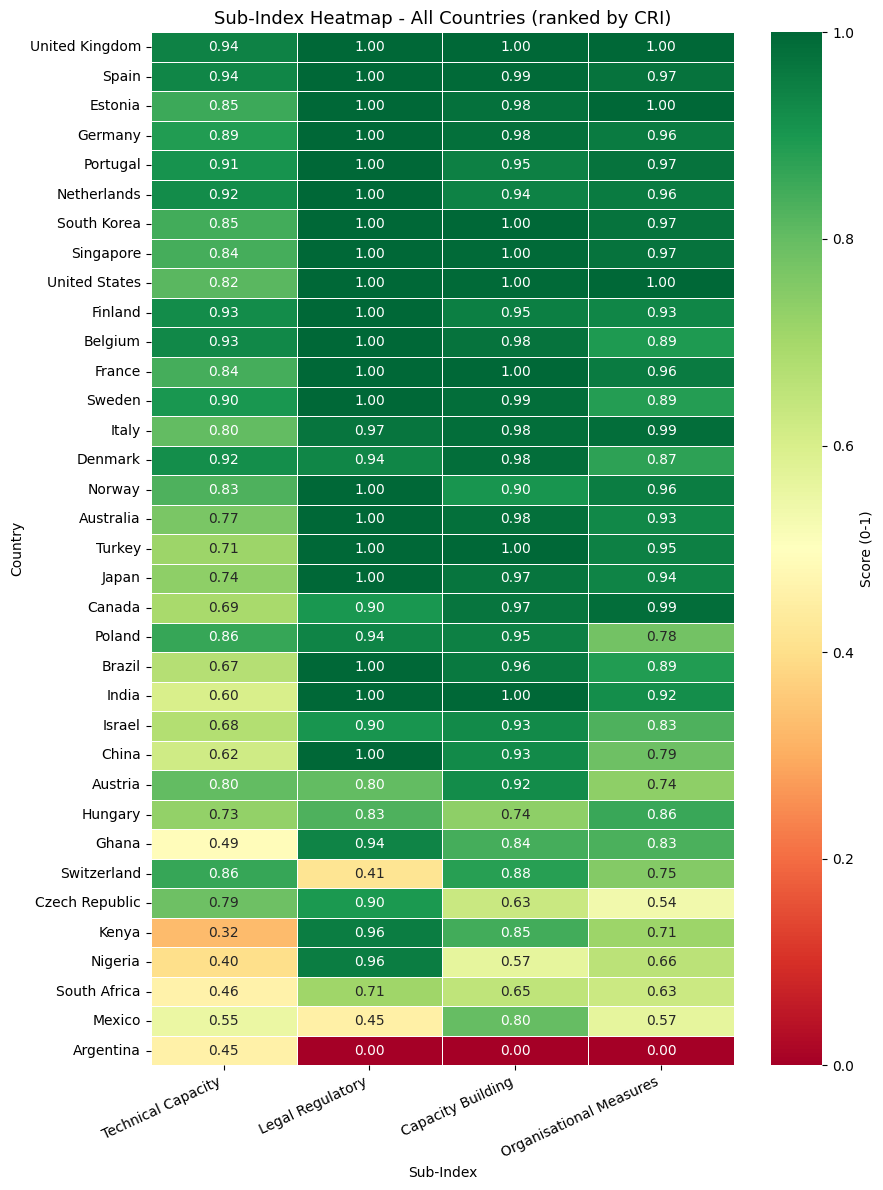

Saved: report/figures/07_subindex_heatmap.png


In [6]:
heatmap_data = df.sort_values('cri_score', ascending=False).set_index('country')[SUB_INDEX_COLS]
heatmap_data.columns = [c.replace('_', ' ').title() for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(9, 12))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'Score (0-1)'}
)
ax.set_title('Sub-Index Heatmap - All Countries (ranked by CRI)', fontsize=13)
ax.set_ylabel('Country')
ax.set_xlabel('Sub-Index')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{FIGURES}07_subindex_heatmap.png', dpi=150)
plt.show()
print('Saved: report/figures/07_subindex_heatmap.png')